# 02 — Split (train / val / test)

Definišemo i zamrzavamo podelu skupa na nivou cele slike:

- **TEST** = 70 celih slika nasumično odabranih kao test set u originalnom radu. Odabrano radi uporedivosti naših rezultata sa.
- Preostalih 213 slika -> **TRAIN/VAL** split 80/20
- fiksni `seed`, stratifikovano tako da udeo praznih maski ostane proporcionalan u train i val skupu.
- Ciljna veličina: val ≈ 20% od 213 (~43 slike), train ~170 (≈ 60/15/25 od ukupno 283).

In [1]:
import sys
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage
from skimage.morphology import remove_small_objects
from skimage.measure import label as sk_label
from src import config
from src.split import make_splits, save_splits, _is_empty

## 1. Lista test slika

Ovih 70 imena je originalna test podela preuzeta iz repoa originalnog rada.

In [2]:
test_img_names = ['Mar21bS1C2R2_VLPAGl_200x_y.png',
                  'Mar20bS1C4R3_DMl_200x_y.png',
                  'Mar19bS1C5R3_DMr_200x_y.png',
                  'Mar27bS1C2R1_LHl_200x_y.png',
                  'Mar19bS1C4R1_VLPAGr_200x_y.png',
                  'Mar19bS1C3R2_VLPAGl_200x_y.png',
                  'Mar26bS1C4R3_DMl_200x_y.png',
                  'Mar21bS1C1R3_VLPAGr_200x_y.png',
                  'Mar20bS1C3R2_VLPAGl_200x_y.png',
                  'Mar22bS1C4R1_LHl_200x_y.png',
                  'Mar24bS1C3R2_LHr_200x_y.png',
                  'Mar20bS1C4R3_DMr_200x_y.png',
                  'Mar20bS1C2R3_VLPAGr_200x_y.png',
                  'Mar20bS1C2R2_VLPAGl_200x_y.png',
                  'Mar26bS1C4R2_LHl_200x_y.png',
                  'Mar19bS1C4R3_DMr_200x_y.png',
                  'Mar24bS1C2R2_LHl_200x_y.png',
                  'Mar20bS2C1R1_LHl_200x_y.png',
                  'Mar19bS1C1R2_VLPAGr_200x_y.png',
                  'Mar24bS2C4R3_DMr_200x_y.png',
                  'Mar23bS1C6R1_DMr_200x_y.png',
                  'Mar19bS1C3R2_VLPAGr_200x_y.png',
                  'Mar24bS1C1R1_LHl_200x_y.png',
                  'Mar21bS2C1R2_LHl_200x_y.png',
                  'Mar21bS1C2R3_VLPAGr_200x_y.png',
                  'Mar19bS1C2R3_VLPAGr_200x_y.png',
                  'Mar20bS2C1R3_DMl_200x_y.png',
                  'Mar26bS2C2R2_DMr_200x_y.png',
                  'Mar21bS1C2R1_VLPAGl_200x_y.png',
                  'Mar22bS1C4R2_LHr_200x_y.png',
                  'Mar22bS1C3R2_DMr_200x_y.png',
                  'Mar24bS2C2R3_VLPAGl_200x_y.png',
                  'Mar24bS1C2R1_DMl_200x_y.png',
                  'Mar20bS1C4R1_DMr_200x_y.png',
                  'Mar19bS1C5R2_DMr_200x_y.png',
                  'Mar20bS2C2R3_LHr_200x_y.png',
                  'Mar21bS2C2R2_LHr_200x_y.png',
                  'Mar20bS1C1R3_VLPAGr_200x_y.png',
                  'Mar22bS2C1R1_LHr_200x_y.png',
                  'Mar20bS1C2R1_VLPAGl_200x_y.png',
                  'Mar19bS1C5R3_LHl_200x_y.png',
                  'Mar26bS2C2R2_LHr_200x_y.png',
                  'Mar19bS1C5R2_DMl_200x_y.png',
                  'Mar26bS2C2R1_DMl_200x_y.png',
                  'Mar22bS1C2R1_VLPAGl_200x_y.png',
                  'Mar20bS2C2R3_LHl_200x_y.png',
                  'Mar19bS1C1R3_VLPAGl_200x_y.png',
                  'Mar27bS1C3R1_LHr_200x_y.png',
                  'Mar24bS1C3R1_LHr_200x_y.png',
                  'Mar24bS1C1R2_DMr_200x_y.png',
                  'Mar19bS1C4R2_LHr_200x_y.png',
                  'Mar21bS2C1R1_LHr_200x_y.png',
                  'Mar20bS1C4R1_LHl_200x_y.png',
                  'Mar26bS2C1R1_DMr_200x_y.png',
                  'Mar19bS1C5R2_LHl_200x_y.png',
                  'Mar21bS2C2R3_LHl_200x_y.png',
                  'Mar19bS1C4R3_LHr_200x_y.png',
                  'Mar23bS2C1R1_LHl_200x_y.png',
                  'Mar23bS1C1R4_VLPAGl_200x_y.png',
                  '39_y.png',
                  'Mar31bS2C1R2_VLPAGr_200x_y.png',
                  'Mar32bS2C2R2_DMl_200x_y.png',
                  'Mar33bS2C1R1_DMl_200x_y.png',
                  'MAR38S1C3R1_LHR_20_o.png',
                  'Mar42S2C4R2_VLPAGr_200x_o.png',
                  'Mar31bS2C3R4_DMr_200x_y.png',
                  'Mar33bS1C4R2_DMl_200x_y.png',
                  'Mar36bS1C6R2_DMr_200x_y.png',
                  'Mar42S2C2R2_DMr_200x_o.png',
                  'MAR55S1C5R3_DMR_20_o.png']

print("broj test imena:", len(test_img_names))

broj test imena: 70


## 2. Kreiranje i čuvanje splita

In [3]:
splits = make_splits(test_img_names)
save_splits(splits)
print("sačuvano u:", config.SPLITS_DIR)
for name, ids in splits.items():
    print(f"  {name}: {len(ids)} slika")

sačuvano u: /Users/ana_velimirovic/Desktop/Ana-priv/ML/projekat/Fluorescent-neuronal-cell-counting/data/splits
  train: 170 slika
  val: 43 slika
  test: 70 slika


test = originalnih 70 slika iz referentnog repoa, radi direktne uporedivosti naših rezultata sa njihovim rezultatima.
<br>
val =nizdvojen stratifikovano po "prazna maska" iz preostalih 213 slika, tako da udeo praznih ostane proporcionalan u train i val skupu
<br>
Split je urađen na nivou cele slike, pre cropovanja na 512×512 (na crop-ovima se radi trening), čime je sprečeno curenje podataka (crops iz iste slike ne mogu završiti u
različitim skupovima).<br>
Rezultujuće liste image-ID-jeva su zamrznute u `data/splits/{train,val,test}_image_ids.txt` i koriste ih svi modeli i evaluacija.

## 3. Verifikacija

Sve provere dole moraju proći (nema curenja podataka, split je smislen).

In [4]:
train, val, test = splits["train"], splits["val"], splits["test"]

print("len(test) ==", len(test), "-> očekivano 70:", len(test) == 70)
print("len(train)+len(val)+len(test) ==", len(train)+len(val)+len(test), "-> očekivano 283:",
      len(train)+len(val)+len(test) == 283)

print("\ntrain ∩ test:", set(train) & set(test))
print("val ∩ test  :", set(val) & set(test))
print("train ∩ val :", set(train) & set(val))

all_ids = set(p.name for p in config.IMG_DIR.glob("*.png"))
print("\nsvih 70 test imena postoji u IMG_DIR:", set(test) <= all_ids)

len(test) == 70 -> očekivano 70: True
len(train)+len(val)+len(test) == 283 -> očekivano 283: True

train ∩ test: set()
val ∩ test  : set()
train ∩ val : set()

svih 70 test imena postoji u IMG_DIR: True


In [5]:
# udeo praznih maski po skupu -> treba da bude ~isti svuda
rows = []
for name, ids in splits.items():
    empty_frac = sum(_is_empty(i) for i in ids) / len(ids)
    rows.append({"skup": name, "n_slika": len(ids), "udeo_praznih": round(empty_frac, 3)})

tabela = pd.DataFrame(rows).set_index("skup")
tabela

,n_slika,udeo_praznih
skup,,
train,170,0.176
val,43,0.186
test,70,0.171


## 4. Operativni prag za uklanjanje šuma (na TRAIN+VAL)

Provizorni `T_EDA = 80` iz sveske 01 računat je nad celim skupom (uključujući test) i služi samo kao
deskriptivna vrednost. Operativni prag, tj. onaj koji ulazi u evaluaciju (brojanje `n_true`/`n_pred` za
metrike kvaliteta) — mora biti nezavisan od test skupa, pa ga izvodimo ovde, na train+val skupu. Koristimo se istim
objektivnim kriterijumom: gde se završava klaster šuma.

Izabrana vrednost ide u `config.MIN_OBJECT_SIZE`.

In [6]:
# veličine svih objekata na TRAIN+VAL maskama (bez filtriranja)
trainval = splits["train"] + splits["val"]
print("slika u train+val:", len(trainval))

sizes_tv = []
for name in trainval:
    m = np.array(Image.open(config.MASK_DIR/name)) > 0
    lab, n = ndimage.label(m)
    if n:
        areas = np.bincount(lab.ravel())[1:]      # površine objekata u px (bez pozadine)
        sizes_tv.extend(areas.tolist())
sizes_tv = np.array(sizes_tv)

print("ukupno objekata (bez filtriranja):", sizes_tv.size)
print("min:", int(sizes_tv.min()), " max:", int(sizes_tv.max()))
for q in [1,5,10,25,50,75,90,99]:
    print(f"  p{q:>2}: {np.percentile(sizes_tv, q):.0f} px")

slika u train+val: 213


ukupno objekata (bez filtriranja): 1561
min: 1  max: 9360
  p 1: 1 px
  p 5: 114 px
  p10: 348 px
  p25: 638 px
  p50: 1048 px
  p75: 1759 px
  p90: 2845 px
  p99: 5787 px


In [7]:
print("uticaj kandidata praga T (uklanja objekte < T) — TRAIN+VAL:")
for T in [10,20,30,40,50,60,80,100]:
    removed = int((sizes_tv < T).sum())
    print(f"  T={T:>3}: uklonjeno {removed:>4}/{sizes_tv.size}  (ostaje {sizes_tv.size-removed})")
print("\n30 najmanjih objekata (px):", sorted(sizes_tv.tolist())[:30])

uticaj kandidata praga T (uklanja objekte < T) — TRAIN+VAL:
  T= 10: uklonjeno   66/1561  (ostaje 1495)
  T= 20: uklonjeno   69/1561  (ostaje 1492)
  T= 30: uklonjeno   69/1561  (ostaje 1492)
  T= 40: uklonjeno   70/1561  (ostaje 1491)
  T= 50: uklonjeno   72/1561  (ostaje 1489)
  T= 60: uklonjeno   77/1561  (ostaje 1484)
  T= 80: uklonjeno   77/1561  (ostaje 1484)
  T=100: uklonjeno   78/1561  (ostaje 1483)

30 najmanjih objekata (px): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


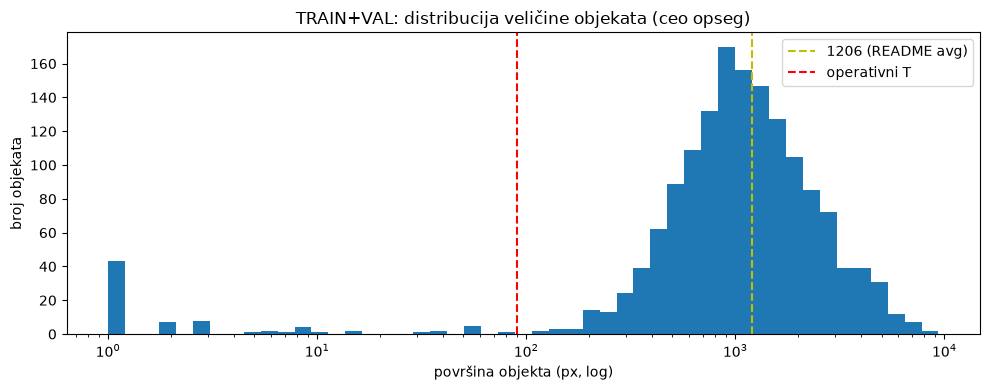

In [22]:
fig, ax = plt.subplots(figsize=(10,4))

ax.hist(sizes_tv, bins=np.logspace(np.log10(sizes_tv.min()), np.log10(sizes_tv.max()), 50))
ax.set_xscale("log")
ax.axvline(1206, color="y", ls="--", label="1206 (README avg)")
ax.axvline(90, color="r", ls="--", label="operativni T")
ax.set_xlabel("površina objekta (px, log)")
ax.set_ylabel("broj objekata")
ax.set_title("TRAIN+VAL: distribucija veličine objekata (ceo opseg)")
ax.legend()

plt.tight_layout(); plt.show()

Operativni prag ćemo postaviti na 90. Međtuim, tvrdnja da izbor praga u opsegu [10,100,10] ne utiče previše na broj detektovanih ćelija idalje stoji, tako da izbor nije od suštinske važnosti.

## 5. Reprezentativnost splita — imbalance i broj ćelija po skupu

Ovo je provera kvaliteta splita, a ne ponavljanje EDA: cilj je da train/val/test budu međusobno
uporedivi, tj. da imaju sličan class imbalance na nivou piksela i slična raspodela udela ćelija po slici.

Napomena: za brojanje ovde koristimo provizorno `T_REF = 80`, isključivo radi poređenja skupova.
Poređenje je robusno na izbor praga u opsegu [10,100], pa ne zavisi od operativne odluke iz 4.

In [9]:
# class imbalance (udeo foreground piksela) po skupu
H, W = 1200, 1600
rows = []
for skup, ids in splits.items():
    fg = np.array([int((np.array(Image.open(config.MASK_DIR/name)) > 0).sum()) for name in ids])
    fg_pct = 100 * fg / (H*W)
    rows.append({"skup": skup, "n_slika": len(ids),
                 "udeo_fg_%": round(100*fg.sum()/(len(ids)*H*W), 3),
                 "medijana_fg%_po_slici": round(float(np.median(fg_pct)), 3),
                 "max_fg%_po_slici": round(float(fg_pct.max()), 3)})
tabela_fg = pd.DataFrame(rows).set_index("skup")
print(tabela_fg.to_string())

       n_slika  udeo_fg_%  medijana_fg%_po_slici  max_fg%_po_slici
skup                                                              
train      170      0.516                  0.403             2.759
val         43      0.585                  0.431             3.419
test        70      0.840                  0.588             5.751


In [10]:
# raspodela broja ćelija po slici, po skupu
T_REF = 80   # px²: provizorno, samo za poređenje skupova (vidi napomenu iznad)

def count_cells(name):
    a = np.array(Image.open(config.MASK_DIR/name)) > 0
    a = remove_small_objects(a, min_size=T_REF)
    _, n = ndimage.label(a)
    return n

rows = []
for skup, ids in splits.items():
    c = np.array([count_cells(name) for name in ids])
    rows.append({"skup": skup, "min": int(c.min()), "medijana": int(np.median(c)),
                 "prosek": round(float(c.mean()), 2), "max": int(c.max()),
                 "praznih": int((c == 0).sum()), ">10_celija": int((c > 10).sum())})
tabela_broj = pd.DataFrame(rows).set_index("skup")
print(tabela_broj.to_string())

/var/folders/zy/p1237_9j4xbgxpvlwy__jnzc0000gn/T/ipykernel_59345/658165108.py:6: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  a = remove_small_objects(a, min_size=T_REF)


       min  medijana  prosek  max  praznih  >10_celija
skup                                                  
train    0         3    6.52   66       32          25
val      0         4    8.72   69        8           7
test     0         5   10.07   68       12          16


Split je reprezentativan po strukturi koju kontrolišemo, uz jednu
nasleđenu asimetriju.

1. *Class imbalance* je očuvan u svim skupovima. Udeo foreground
piksela je <1% svuda (train 0.516%, val 0.585%, test 0.840%), što je u skladu sa 0.607% nad celim
skupom (4.2 iz sveske `01_eda.ipynb`). dakle motivacija za weighted loss važi, a train imbalance (0.516%) je ono
što loss zaista rešava.
2. *Stratifikacija po praznim maskama je uspela* — udeo praznih je
~izjednačen (train 18.8%, val 18.6%, test 17.1%), kako je i ciljano.
3. *Slike u test skupu su sistematski gušće od train/val:* to vidimo u većem udelu foreground-a (0.84% vs 0.52%), u višaim vrednostima medijane/proseka
broja ćelija (test 5/10.07 vs train 3/6.52; val između), i proporcionalno višoj gustih slika
(>10 ćelija: test 16.70=22.9%, val 7/43=16.3%, train 25/170=14.7%).

Treba napomenuti da ovo nije greška našeg splita jer je test je fiksna,
nasleđena lista od 70 slika uzeta radi uporedivosti sa originalnim radom, a mi smo
stratifikovali samo train/val i samo po praznini, ne po gustini — pa je asimetrija svojstvo
nasleđene test liste, ne naše podele.

**Implikacija za evaluaciju:** model se trenira na relativno
ređim slikama a evaluira na gušćim, gde su zbijene/dodirujuće ćelije (teži recall, vidi 4.4 iz `01_eda.ipynb`)
češće. Ovo nam govori test metrike su verovatno konzervativna procena, a greške će se koncentrisati na guste
slike. Asimetriju prihvatamo i dokumentujemo (ne re-splitujemo).